# Comparision of different PRNGs (Model 1)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the tables for model 1 shown in the report.

In [40]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Load and process data

In [41]:
data = [
    {"name": "Exponential", "nameSmall": "exponential", "file": "statistics/results1ExpAutocorrelation.txt", "mean": 200, "std": 200},
    {"name": "Logarithmic", "nameSmall": "logarithmic", "file": "statistics/results1LogAutocorrelation.txt", "mean": 200, "std": 50},
    {"name": "Gamma", "nameSmall": "gamma", "file": "statistics/results1GammaAutocorrelation.txt", "mean": 200, "std": 50},
    {"name": "Triangular", "nameSmall": "triangular", "file": "statistics/results1TriangularAutocorrelation.txt", "mean": 200, "std": 50},
    {"name": "Poisson", "nameSmall": "Poisson", "file": "statistics/results1PoissonAutocorrelation.txt", "mean": 200, "std": math.sqrt(200)},
    {"name": "Geometric", "nameSmall": "geometric", "file": "statistics/results1GeometricAutocorrelation.txt", "mean": 200, "std": math.sqrt(201 * 200)}
]

In [42]:
for i in range(len(data)):
    data[i]["df"] = pd.read_csv(data[i]["file"], header=None, names=["rng_mode", "n", "mean", "std", "rho1", "rho2", "rho3", "rhoSum", "time"], sep="\t")

In [43]:
generators=data[0]["df"]["rng_mode"].drop_duplicates().tolist()

### Colors for generator types

In [44]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

def color_labels(ax):
    for label in ax.get_xticklabels():
        label.set_color(color_from_name(label.get_text()))

def color_boxes(ax):
    for i, generator in enumerate(generators):
        c = color_from_name(generator)
        if c == 'black':
            continue
        ax.axvspan(0.5+i, 1.5+i, facecolor=c, alpha=0.1, edgecolor='none', zorder=-10)

def color_all(fig):
    axes = fig.axes
    for ax in axes:
        color_boxes(ax)
    color_labels(axes[-1])

### Helper functions for generating autocorrelation plots

In [45]:
def plot_autocorrelation_at_Lag(i):
    key = "rho" + str(i)
    info = "at lag " + str(i)
    fig, ax = plot_autocorrelation(key, info, list(range(6)), -0.2, 0.2, 1)
    ax[-1].set_xticklabels(generators + generators + generators + generators + generators + generators, rotation=90, ha='right')
    return fig


def plot_autocorrelation(key, info, indices, ylim_min, ylim_max, decimals):
    fig, ax = plt.subplots(len(indices), 1, figsize=(10, 3.5*len(indices)), sharex='col')

    for i, index in enumerate(indices):
        df = data[index]["df"]
        name = data[index]["nameSmall"]
        ax[i].boxplot([df[df["rng_mode"] == generator][key] * 100 for generator in generators], showmeans=True)
        ax[i].set_title(f"Autocorrelation {info} for {name} distribution")  # , y=1.0, pad=-14
        ax[i].set_ylabel("Autocorrelation")
        ax[i].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=decimals))
        ax[i].set_ylim(ylim_min, ylim_max)

    ax[-1].set_xlabel("PRNG")
    color_all(fig)

    return fig, ax

## Autocorrelation at lag $i$

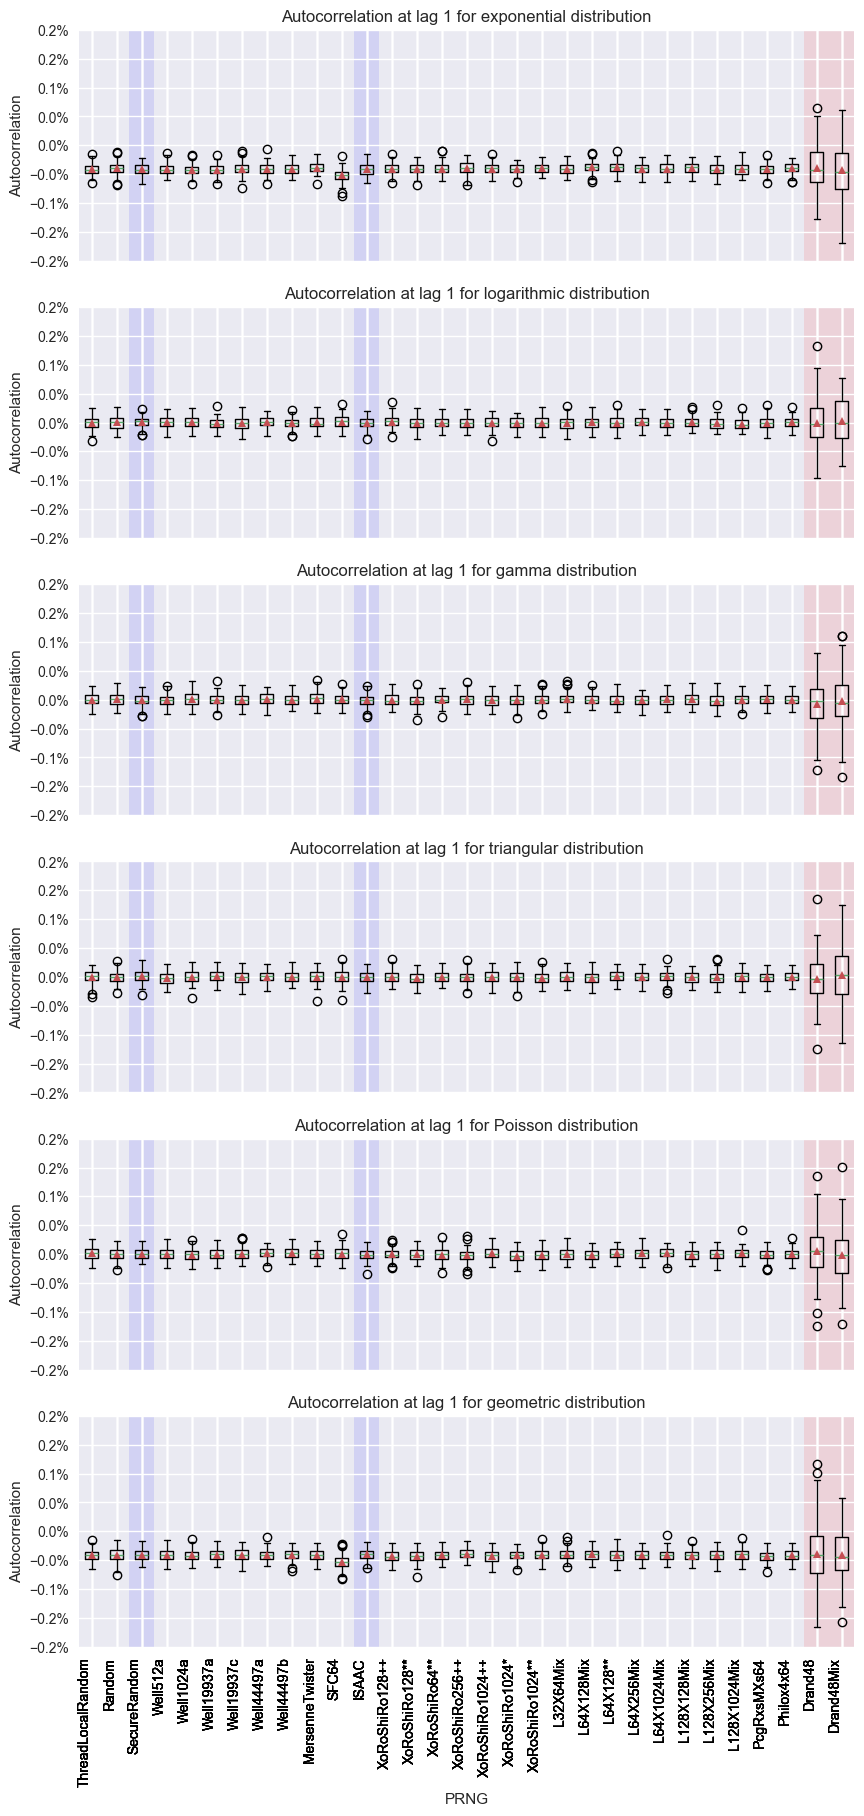

In [ ]:
fig = plot_autocorrelation_at_Lag(1)

# fig.savefig("plot1autocorrelation1.png", format="png", bbox_inches='tight', pad_inches=0)

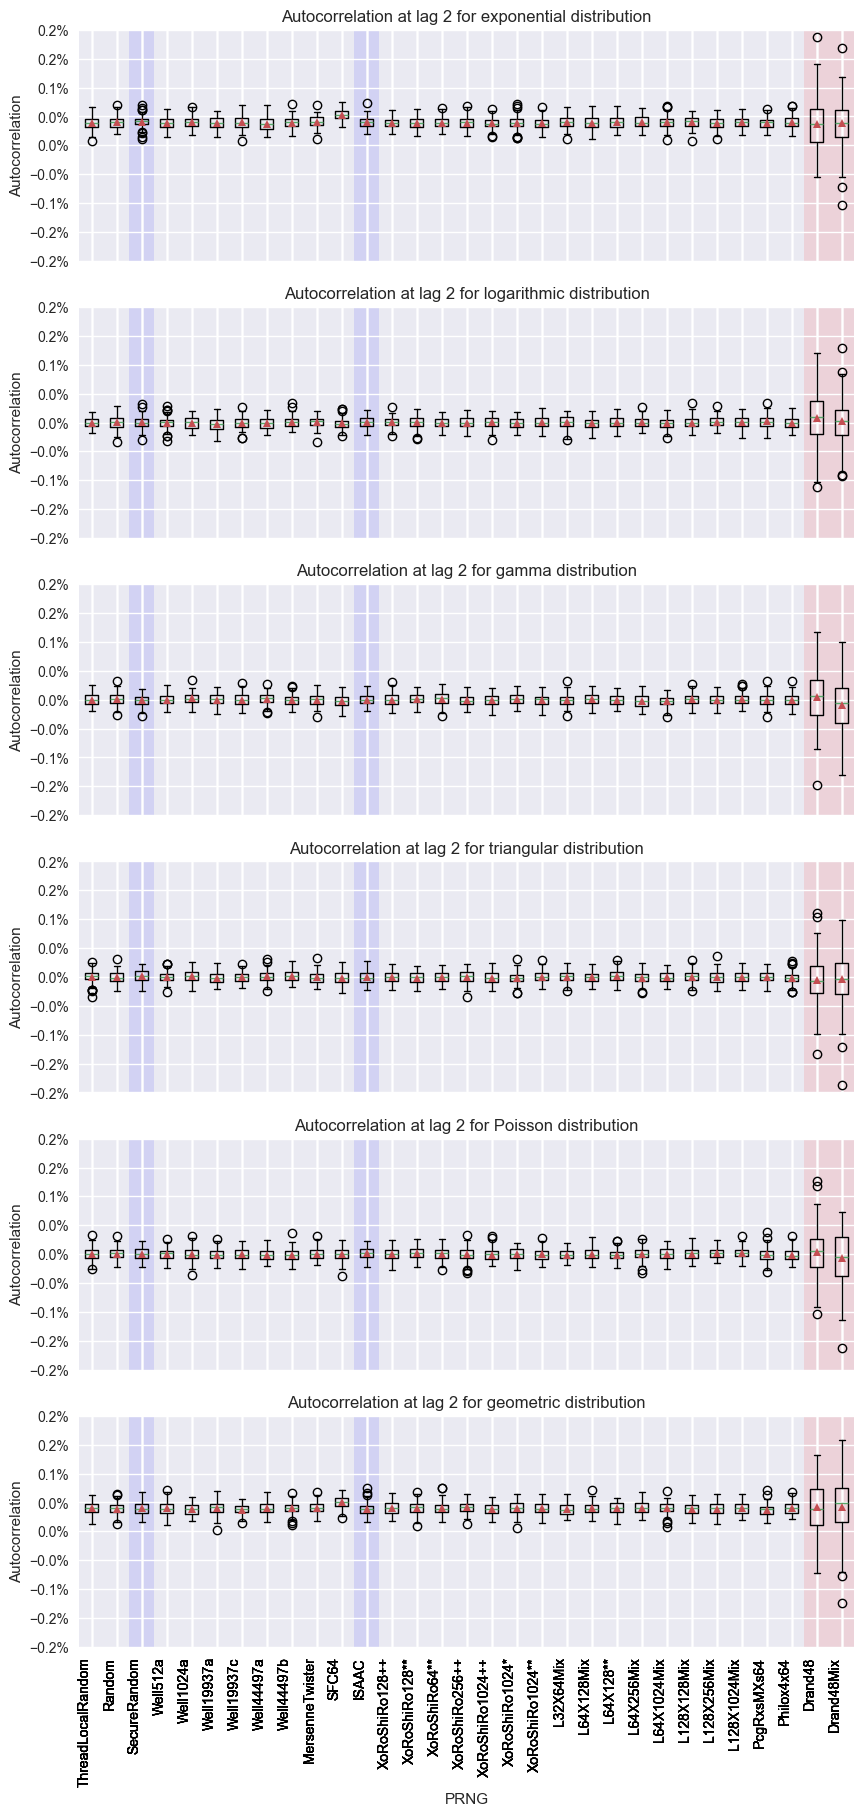

In [ ]:
fig = plot_autocorrelation_at_Lag(2)

# fig.savefig("plot1autocorrelation2.png", format="png", bbox_inches='tight', pad_inches=0)

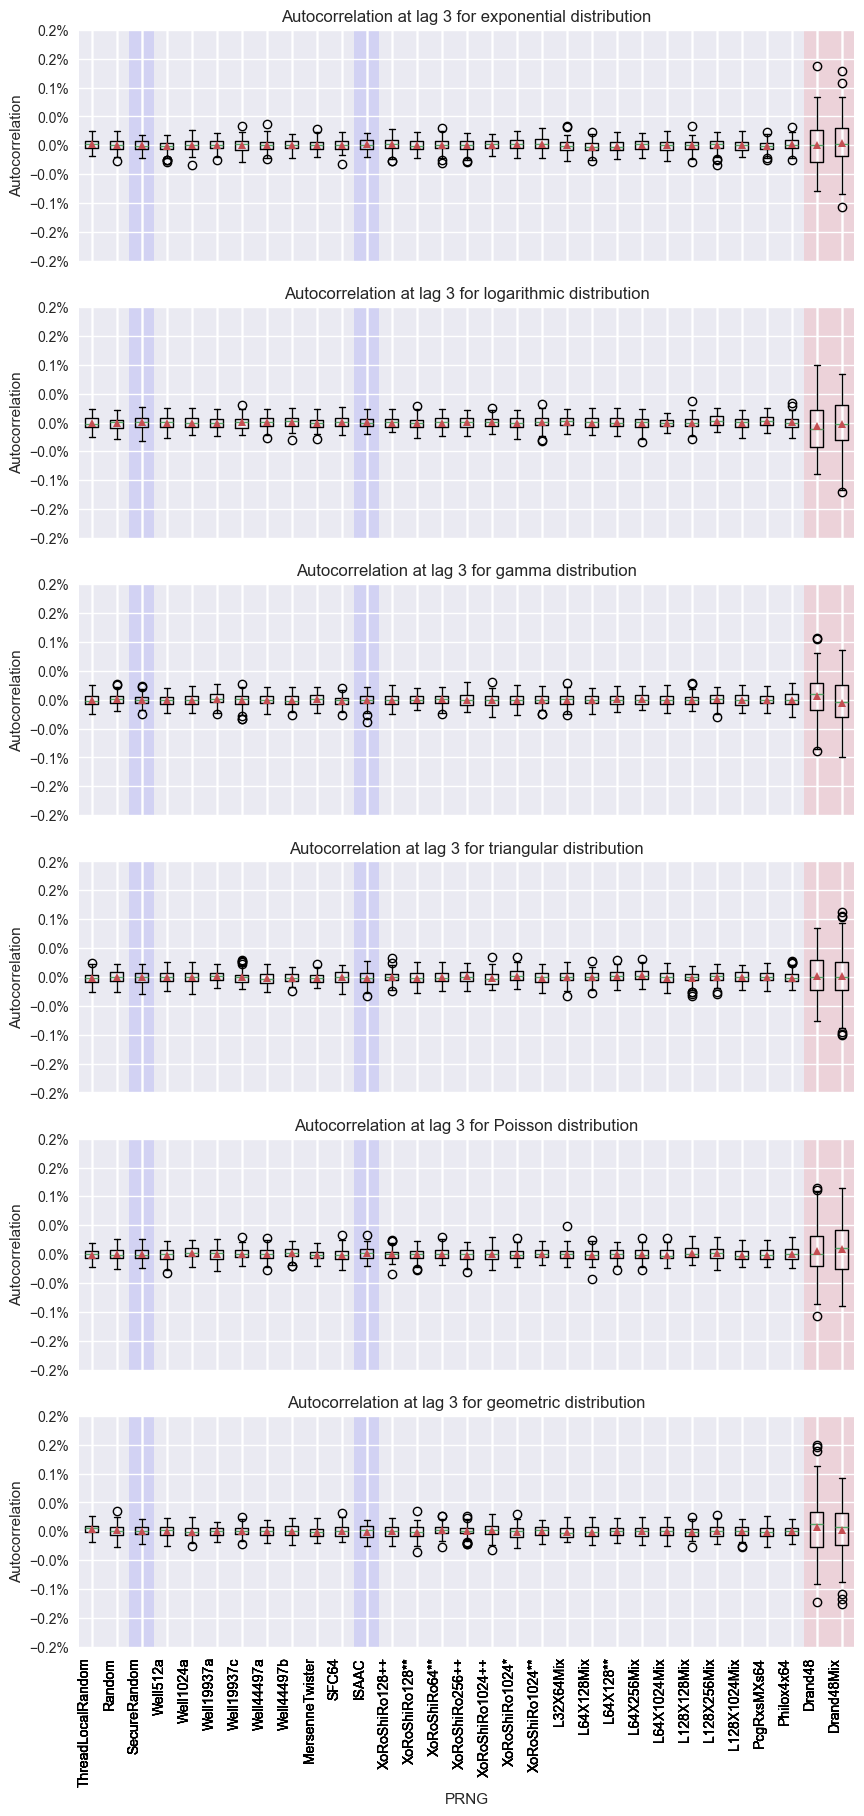

In [ ]:
fig = plot_autocorrelation_at_Lag(3)

# fig.savefig("plot1autocorrelation3.png", format="png", bbox_inches='tight', pad_inches=0)

## Absolute sum of autocorrelation at lags 1 to 100

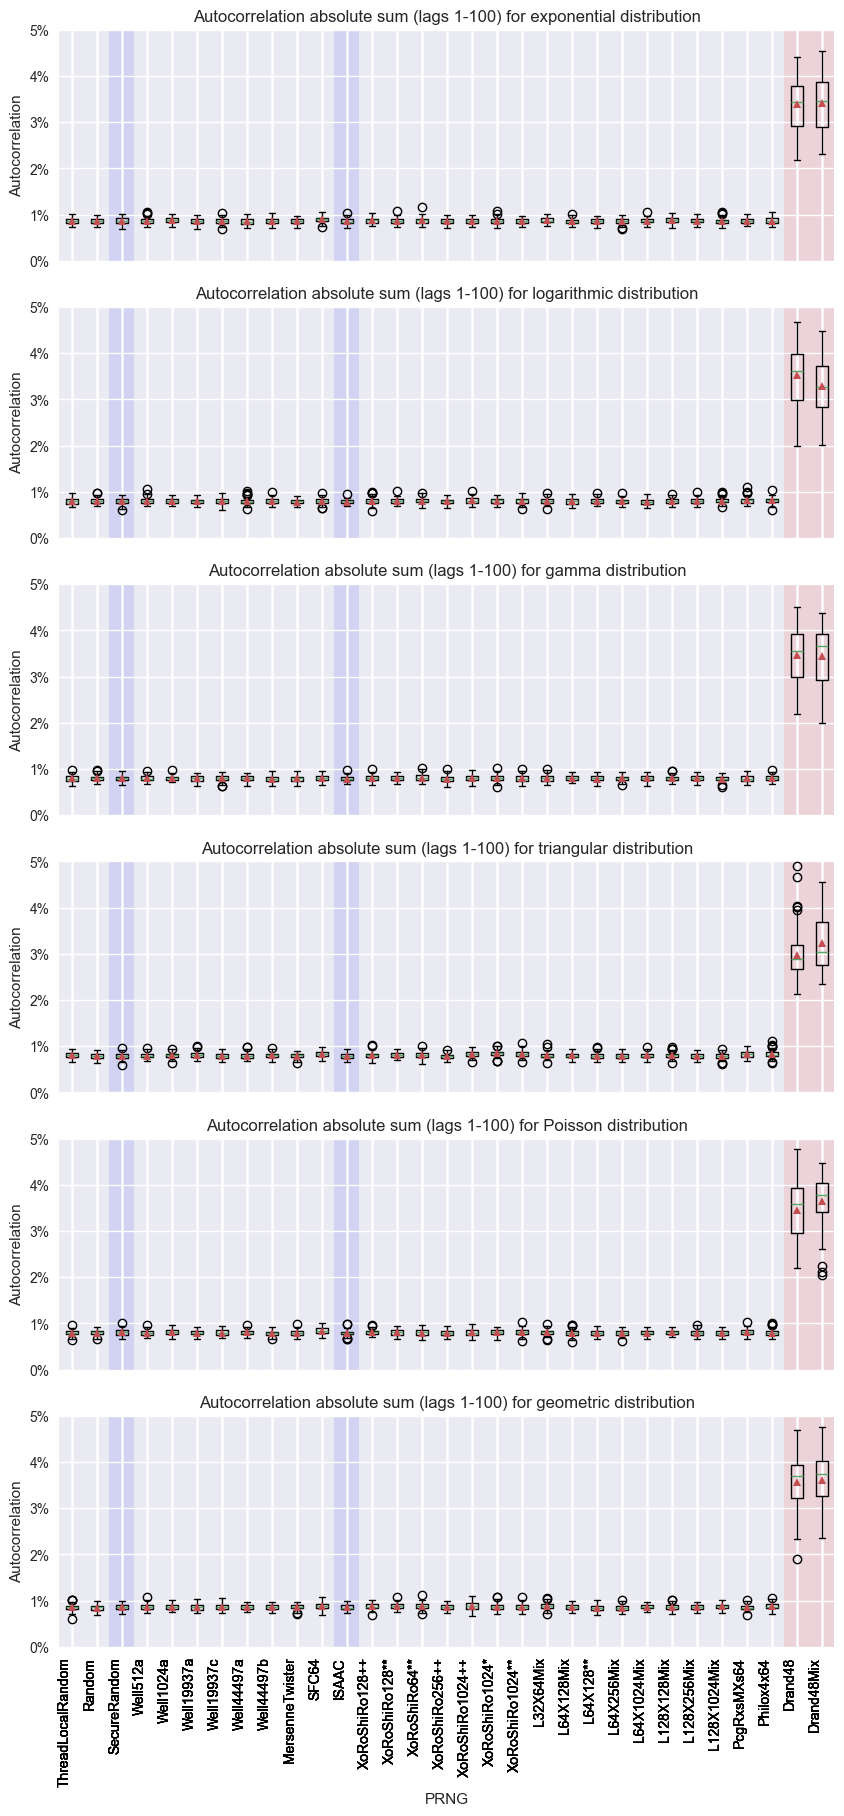

In [ ]:
key = "rhoSum"
info = "absolute sum (lags 1-100)"
indices = list(range(6))
fig, ax = plot_autocorrelation(key, info, indices, 0, 5, 0)
ax[-1].set_xticklabels(generators + generators + generators + generators + generators + generators, rotation=90, ha='right')

# fig.savefig("plot1autocorrelationSum.png", format="png", bbox_inches='tight', pad_inches=0)

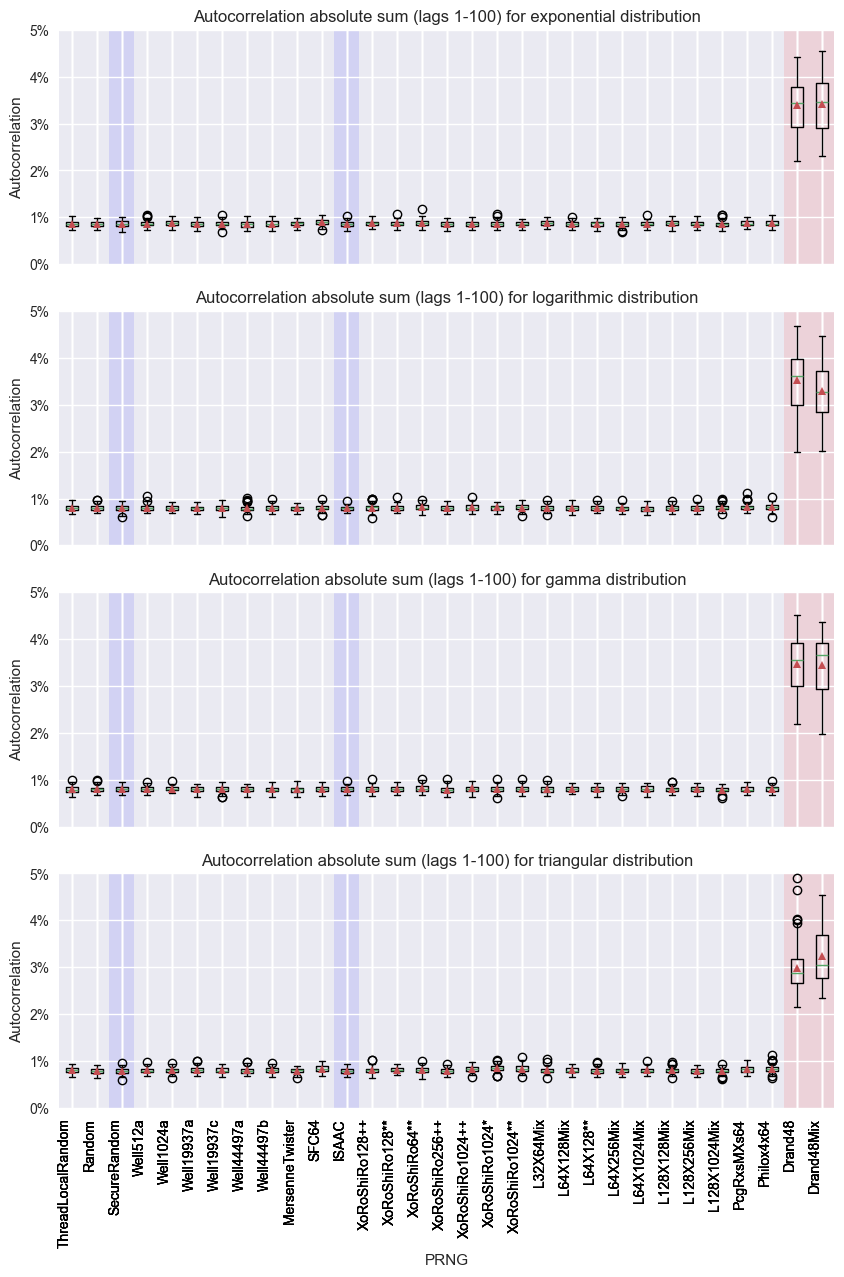

In [ ]:
key = "rhoSum"
info = "absolute sum (lags 1-100)"
indices = list(range(4))
fig, ax = plot_autocorrelation(key, info, indices, 0, 5, 0)
ax[-1].set_xticklabels(generators + generators + generators + generators, rotation=90, ha='right')

# fig.savefig("plot1autocorrelation_a.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

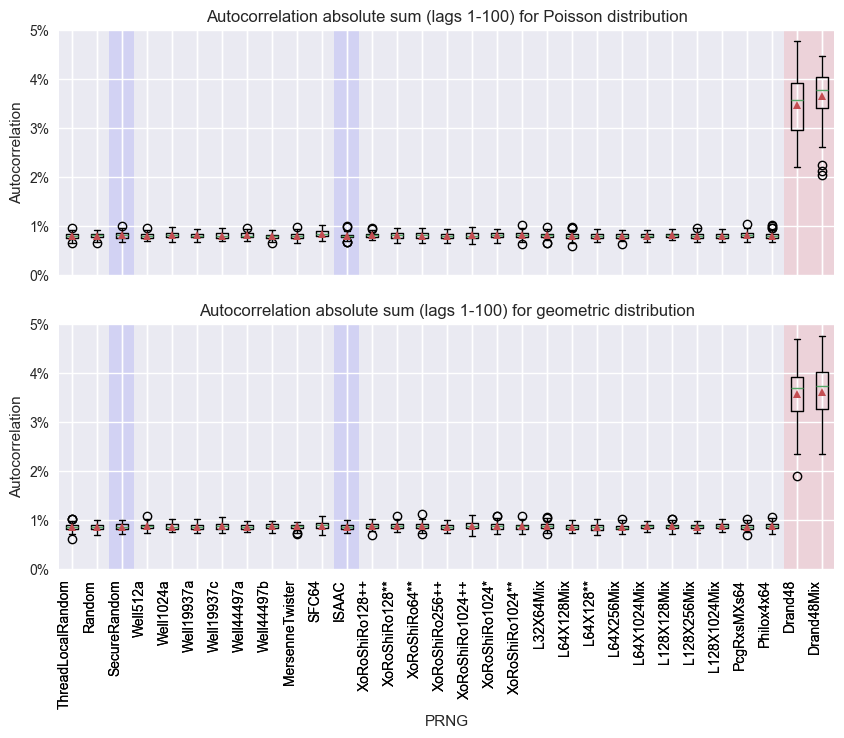

In [ ]:
key = "rhoSum"
info = "absolute sum (lags 1-100)"
indices = list(range(4, 6))
fig, ax = plot_autocorrelation(key, info, indices, 0, 5, 0)
ax[-1].set_xticklabels(generators + generators, rotation=90, ha='right')

# fig.savefig("plot1autocorrelation_b.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

In [52]:
d={}
for rec in data:
    df = rec["df"]
    col = [df[df["rng_mode"] == generator]["rhoSum"].mean()*100 for generator in generators]  # Values are in percentage
    d[rec["name"]] = col

table = pd.DataFrame(d, index=generators)

table

,Exponential,Logarithmic,Gamma,Triangular,Poisson,Geometric
ThreadLocalRandom,0.864074,0.796462,0.796231,0.810268,0.796074,0.854329
Random,0.861238,0.807024,0.802094,0.784836,0.801577,0.851379
SecureRandom,0.867426,0.793797,0.795505,0.788887,0.804229,0.861220
Well512a,0.865525,0.804673,0.800682,0.799433,0.797231,0.867078
Well1024a,0.881311,0.800827,0.807106,0.803854,0.808115,0.863019
Well19937a,0.858710,0.794082,0.798157,0.811055,0.804048,0.857193
Well19937c,0.865448,0.802440,0.799458,0.799195,0.801748,0.867658
Well44497a,0.853494,0.791177,0.795984,0.797142,0.809485,0.855668
Well44497b,0.864871,0.798451,0.792483,0.803789,0.791249,0.864549
MersenneTwister,0.868098,0.790081,0.796600,0.795915,0.796277,0.865497


In [53]:

s = table.style.format("{:.1f}\\,\\%").set_caption("Autocorrelation absolute sum (in \\%)").set_table_styles([{
    "selector": "caption",
    "props": []
}])
print(s.to_latex())

\begin{table}
\caption{Autocorrelation absolute sum (in \%)}
\begin{tabular}{lrrrrrr}
 & Exponential & Logarithmic & Gamma & Triangular & Poisson & Geometric \\
ThreadLocalRandom & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Random & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
SecureRandom & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Well512a & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Well1024a & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Well19937a & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Well19937c & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Well44497a & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
Well44497b & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
MersenneTwister & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
SFC64 & 0.9\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.8\,\% & 0.9\,\% \\
ISAAC & 0.9\,\% & 0.8\,